# **🏡 House Price Prediction**

This notebook performs a complete **data preprocessing + visualization + machine learning** workflow on the **House Price Prediction** dataset.  
The goal is to understand the dataset, clean it, encode categorical columns, and finally train multiple ML models to predict **SalePrice**.

---

## 🔎 **What This Code Does**

### **1️⃣ Loads and Inspects the Dataset**
- Reads the Excel file  
- Shows the first 5 rows  
- Displays dataset shape  
- Identifies:
  - Categorical columns  
  - Integer columns  
  - Float columns  

---

### **2️⃣ Exploratory Data Analysis (EDA)**
- Creates a correlation heatmap of numerical features  
- Plots the number of unique values for each categorical feature  
- Shows distribution plots for all categorical columns  

---

### **3️⃣ Data Cleaning**
- Drops the `Id` column (if present)  
- Fills missing values in `SalePrice` with mean  
- Drops all remaining rows that contain missing data  

---

### **4️⃣ Categorical Encoding (One-Hot Encoding)**
- Detects all categorical columns  
- Converts them into numerical indicator variables  
- Merges encoded columns back into the dataset  

---

### **5️⃣ Dataset Preparation**
- Splits data into:
  - **Features (X)**
  - **Target (Y = SalePrice)**
- Performs 80/20 train–validation split  
- Displays shape of training and validation sets  

---

### **6️⃣ Machine Learning Models Trained**
The following three ML models are trained **without any deep learning or epochs**:

#### ✔ Support Vector Regressor (SVR)  
#### ✔ Random Forest Regressor  
#### ✔ Linear Regression  

Each model produces a **MAPE (Mean Absolute Percentage Error)** score to evaluate prediction accuracy.

---

## 🎯 **Final Outcome**

By the end of this code execution, you will have:

- A fully cleaned and encoded dataset  
- Visual insights from EDA  
- Three trained ML models  
- Performance comparison through MAPE values  
- A ready-to-use pipeline for regression-based house price prediction  



================ HEAD (First 5 Rows) ================
   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  

================ DATASET SHAPE ================
Dataset

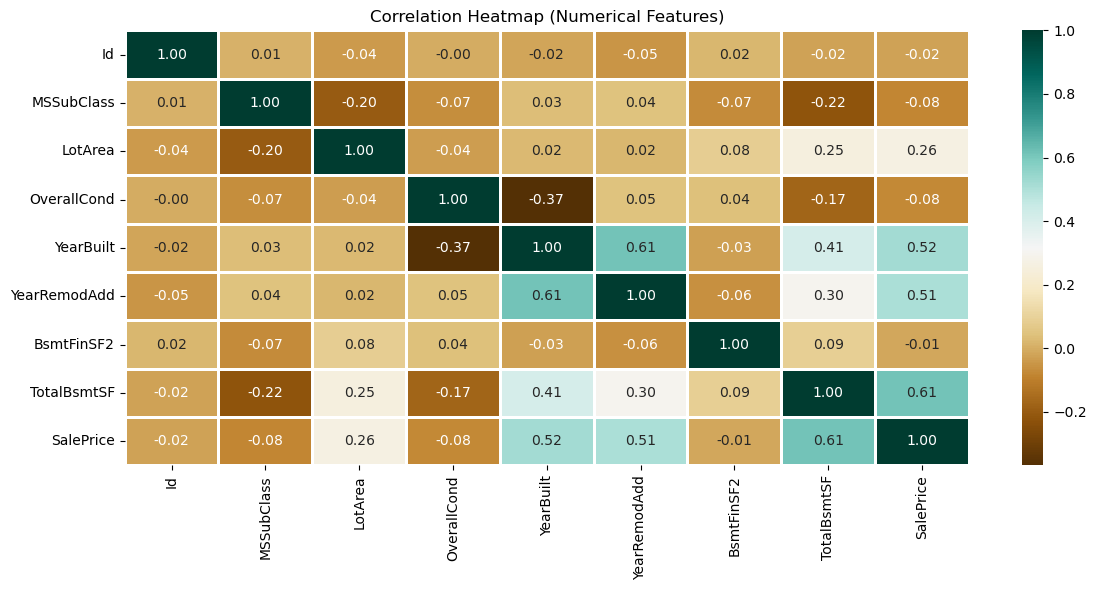

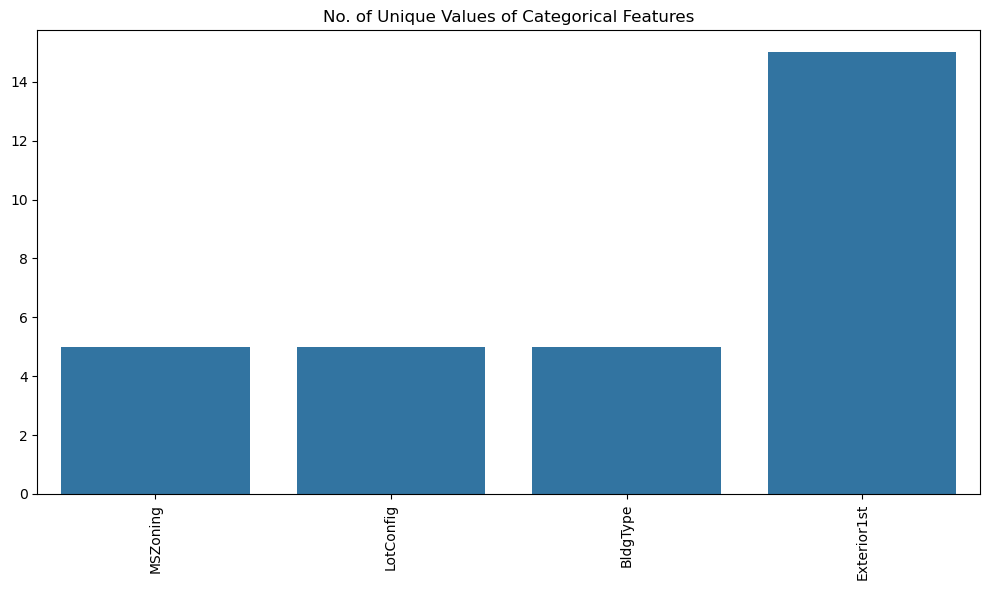

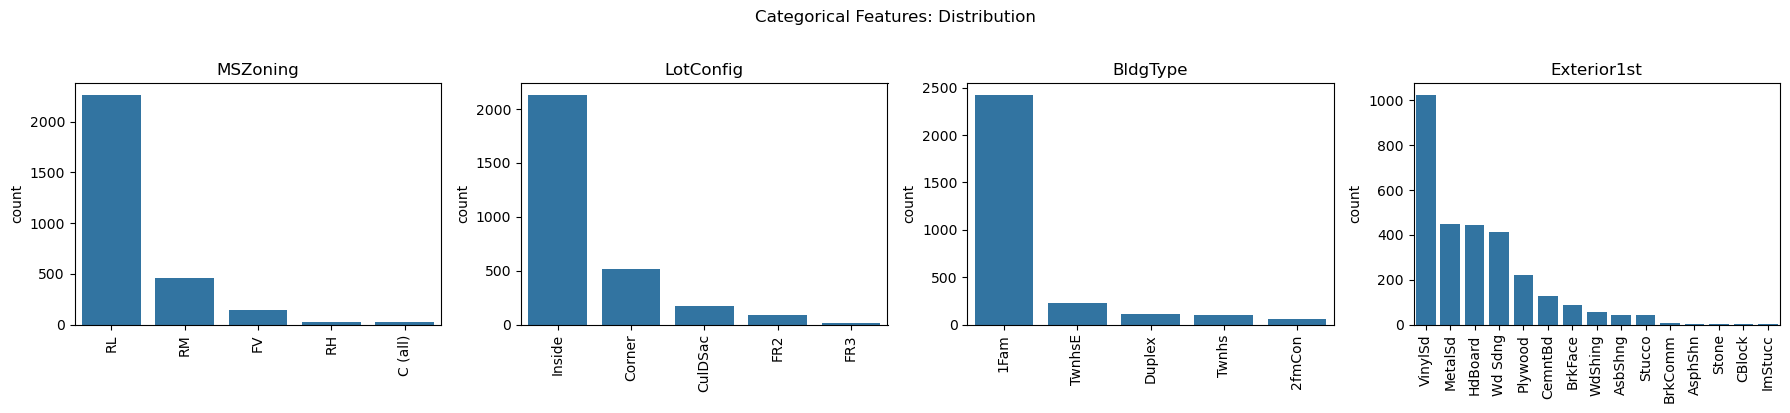


================ DATASET AFTER DROPPING NA ================
New dataset shape after dropping NA: (2913, 12)
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64
Categorical variables after cleaning:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of categorical features: 4

================ FINAL DATASET AFTER ENCODING ================
Final dataset shape after encoding: (2913, 38)

================ TRAIN / VALID SHAPES ================
X_train shape: (2330, 37)
X_valid shape: (583, 37)

================ MODEL PERFORMANCE ================
SVR MAPE: 0.1870512931870423
Random Forest Regressor MAPE: 0.18682554410266083
Linear Regression MAPE: 0.18741683841599951


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


# Load dataset
dataset = pd.read_excel("HousePricePrediction.xlsx")

# Basic info
print("\n================ HEAD (First 5 Rows) ================")
print(dataset.head(5))
print("\n================ DATASET SHAPE ================")
print("Dataset shape:", dataset.shape)

# Identify categorical and numerical columns using select_dtypes
object_cols = dataset.select_dtypes(include=["object"]).columns.tolist()
print("\n================ CATEGORICAL VARIABLES ================")
print("Categorical variables :", len(object_cols))
print(object_cols)

int_cols = dataset.select_dtypes(include=["int", "int32", "int64"]).columns.tolist()
print("\n================ INTEGER VARIABLES ================")
print("Integer variables :", len(int_cols))
print(int_cols)

float_cols = dataset.select_dtypes(include=["float", "float32", "float64"]).columns.tolist()
print("\n================ FLOAT VARIABLES ================")
print("Float variables :", len(float_cols))
print(float_cols)

# Correlation heatmap for numerical features only
numerical_dataset = dataset.select_dtypes(include=["number"])

if numerical_dataset.shape[1] > 1:
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        numerical_dataset.corr(),
        cmap="BrBG",
        fmt=".2f",
        linewidths=2,
        annot=True,
    )
    plt.title("Correlation Heatmap (Numerical Features)")
    plt.tight_layout()
    plt.show()

# Unique values for categorical columns
unique_values = []
for col in object_cols:
    unique_values.append(dataset[col].nunique())

if object_cols:
    plt.figure(figsize=(10, 6))
    plt.title("No. of Unique Values of Categorical Features")
    plt.xticks(rotation=90)
    sns.barplot(x=object_cols, y=unique_values)
    plt.tight_layout()
    plt.show()

# Distribution of categorical features
if object_cols:
    from math import ceil

    n_cols = 4
    n_rows = ceil(len(object_cols) / n_cols)

    plt.figure(figsize=(18, 4 * n_rows))
    plt.suptitle("Categorical Features: Distribution", y=1.02)

    index = 1
    for col in object_cols:
        y = dataset[col].value_counts()
        plt.subplot(n_rows, n_cols, index)
        plt.xticks(rotation=90)
        sns.barplot(x=list(y.index), y=y)
        plt.title(col)
        index += 1

    plt.tight_layout()
    plt.show()

# Drop ID column if present
if "Id" in dataset.columns:
    dataset.drop(["Id"], axis=1, inplace=True)

# Handle target missing values
if dataset["SalePrice"].isnull().any():
    dataset["SalePrice"] = dataset["SalePrice"].fillna(dataset["SalePrice"].mean())

# Drop remaining rows with missing values
new_dataset = dataset.dropna()
print("\n================ DATASET AFTER DROPPING NA ================")
print("New dataset shape after dropping NA:", new_dataset.shape)
print(new_dataset.isnull().sum())

# One-hot encode categorical variables
s = new_dataset.dtypes == "object"
object_cols = list(s[s].index)
print("Categorical variables after cleaning:")
print(object_cols)
print("No. of categorical features:", len(object_cols))

# Handle sklearn version differences for OneHotEncoder
try:
    OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
except TypeError:
    # For older versions of scikit-learn
    OH_encoder = OneHotEncoder(sparse=False, handle_unknown="ignore")

OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()

# Final dataframe after encoding
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)
print("\n================ FINAL DATASET AFTER ENCODING ================")
print("Final dataset shape after encoding:", df_final.shape)

# Split into features and target
X = df_final.drop(["SalePrice"], axis=1)
Y = df_final["SalePrice"]

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=0
)

print("\n================ TRAIN / VALID SHAPES ================")
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

# ------------------ Models ------------------

# 1. Support Vector Regressor
model_SVR = svm.SVR()
model_SVR.fit(X_train, Y_train)
Y_pred_svr = model_SVR.predict(X_valid)

mape_svr = mean_absolute_percentage_error(Y_valid, Y_pred_svr)
print("\n================ MODEL PERFORMANCE ================")
print("SVR MAPE:", mape_svr)

# 2. Random Forest Regressor
model_RFR = RandomForestRegressor(n_estimators=100, random_state=42)
model_RFR.fit(X_train, Y_train)
Y_pred_rfr = model_RFR.predict(X_valid)

mape_rfr = mean_absolute_percentage_error(Y_valid, Y_pred_rfr)
print("Random Forest Regressor MAPE:", mape_rfr)

# 3. Linear Regression
model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred_lr = model_LR.predict(X_valid)

mape_lr = mean_absolute_percentage_error(Y_valid, Y_pred_lr)
print("Linear Regression MAPE:", mape_lr)
